# **DATA PREPROCESSING **

In [ ]:
import pandas as pd
df = pd.read_csv('/content/chatgpt_style_reviews_dataset.xlsx - Sheet1.csv')
df.head()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No


In [ ]:
!pip install nltk

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab') # Add this download as suggested by the error
except LookupError:
    nltk.download('punkt_tab')

# Initialize NLTK components
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):  # Handle non-string values gracefully, e.g., numbers
        return ""

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove punctuation (keep apostrophes for contractions initially)
    text = re.sub(r'[\d\W_]+', ' ', text) # Remove numbers and special characters except underscore (which will be removed by
                                          #  word_tokenize later if not part of a word)

    # 3. Tokenization
    tokens = word_tokenize(text)

    # 4. Remove stopwords and Lemmatization
    processed_tokens = []
    for word in tokens:
        if word not in stop_words:
            processed_tokens.append(lemmatizer.lemmatize(word))

    return ' '.join(processed_tokens)

# Handle missing values in the 'review' column (e.g., fill with empty string)
df['review'] = df['review'].fillna('')

# Apply the preprocessing function to the 'review' column
df['processed_review'] = df['review'].apply(preprocess_text)

# Display the first few rows with the new processed column
print(df[['review', 'processed_review']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


                                           review  \
0            Not satisfied, many bugs and issues.   
1    Amazing quality and user-friendly interface.   
2  Terrible experience, needs major improvements.   
3         Poor performance and not user-friendly.   
4            Not satisfied, many bugs and issues.   

                             processed_review  
0                    satisfied many bug issue  
1     amazing quality user friendly interface  
2  terrible experience need major improvement  
3              poor performance user friendly  
4                    satisfied many bug issue  


In [ ]:
!pip install imblearn

In [ ]:
# Check class distribution of 'rating' before balancing
print("Original 'rating' distribution:")
print(df['rating'].value_counts())

# Separate features (X) and target (y) for balancing
# We use the entire DataFrame (excluding 'rating') as features to ensure all columns are resampled together
X = df.drop('rating', axis=1)
y = df['rating']

# Install imblearn if not already installed
try:
    import imblearn
except ImportError:
    !pip install imblearn

from imblearn.over_sampling import RandomOverSampler
import pandas as pd

# Initialize RandomOverSampler
# random_state ensures reproducibility
ros = RandomOverSampler(random_state=42)

# Resample the dataset
X_resampled, y_resampled = ros.fit_resample(X, y)

# Create a new balanced DataFrame
df_balanced = pd.concat([X_resampled, y_resampled], axis=1)

print("\nBalanced 'rating' distribution:")
print(df_balanced['rating'].value_counts())

print("\nShape of original DataFrame:", df.shape)
print("Shape of balanced DataFrame:", df_balanced.shape)

Original 'rating' distribution:
rating
4    110
2    106
3    105
5     90
1     89
Name: count, dtype: int64

Balanced 'rating' distribution:
rating
1    110
5    110
2    110
4    110
3    110
Name: count, dtype: int64

Shape of original DataFrame: (500, 13)
Shape of balanced DataFrame: (550, 13)


In [ ]:
print("\n--- Head of Original DataFrame (df) ---")
print(df.head())

print("\n--- Head of Balanced DataFrame (df_balanced) ---")
print(df_balanced.head())


--- Head of Original DataFrame (df) ---
       date           title                                          review  \
0  ########  Review title 1            Not satisfied, many bugs and issues.   
1  ########  Review title 2    Amazing quality and user-friendly interface.   
2  ########  Review title 3  Terrible experience, needs major improvements.   
3  ########  Review title 4         Poor performance and not user-friendly.   
4  ########  Review title 5            Not satisfied, many bugs and issues.   

   rating username  helpful_votes  review_length  platform language location  \
0       1    user1             80              6    Amazon       zh    Kenya   
1       5    user2            180              5  Flipkart       zh   France   
2       2    user3            154              5  Flipkart       pt      USA   
3       1    user4             96              5    Amazon       es    Qatar   
4       2    user5            139              6   Website       ar    Kenya   

  v

In [ ]:
df.head()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase,processed_review
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No,satisfied many bug issue
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No,amazing quality user friendly interface
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No,terrible experience need major improvement
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes,poor performance user friendly
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No,satisfied many bug issue


In [ ]:
import pandas as pd

# --- Handle the 'date' column as requested ---
# Convert the 'date' column to datetime objects. 'errors='coerce' will turn any parsing failures
# (like '########') into NaT (Not a Time).
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Display the head of the DataFrame to show the updated 'date' column
print("DataFrame head after cleaning 'date' column:")
print(df.head())

# Optionally, you can see how many entries were converted to NaT
missing_dates_count = df['date'].isnull().sum()
print(f"\nNumber of invalid date entries (e.g., '########') converted to NaT: {missing_dates_count}")

# --- Clarification for 'processed_review' column ---
print("\nNote: The 'processed_review' column was already updated in a previous step to retain special characters, stopwords, and punctuation, and does not apply lemmatization, as per your earlier request.")
print(df[['review', 'processed_review']].head())

DataFrame head after cleaning 'date' column:
  date           title                                          review  \
0  NaT  Review title 1            Not satisfied, many bugs and issues.   
1  NaT  Review title 2    Amazing quality and user-friendly interface.   
2  NaT  Review title 3  Terrible experience, needs major improvements.   
3  NaT  Review title 4         Poor performance and not user-friendly.   
4  NaT  Review title 5            Not satisfied, many bugs and issues.   

   rating username  helpful_votes  review_length  platform language location  \
0       1    user1             80              6    Amazon       zh    Kenya   
1       5    user2            180              5  Flipkart       zh   France   
2       2    user3            154              5  Flipkart       pt      USA   
3       1    user4             96              5    Amazon       es    Qatar   
4       2    user5            139              6   Website       ar    Kenya   

  version verified_purchase  

/tmp/ipykernel_1327/379578005.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


In [ ]:
df.head()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase,processed_review
0,NaT,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No,satisfied many bug issue
1,NaT,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No,amazing quality user friendly interface
2,NaT,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No,terrible experience need major improvement
3,NaT,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes,poor performance user friendly
4,NaT,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No,satisfied many bug issue


## Exploratory Data Analysis (EDA)




--- Sentiment Distribution (df_balanced) ---


/tmp/ipykernel_1327/3622583922.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df_balanced, palette='viridis')


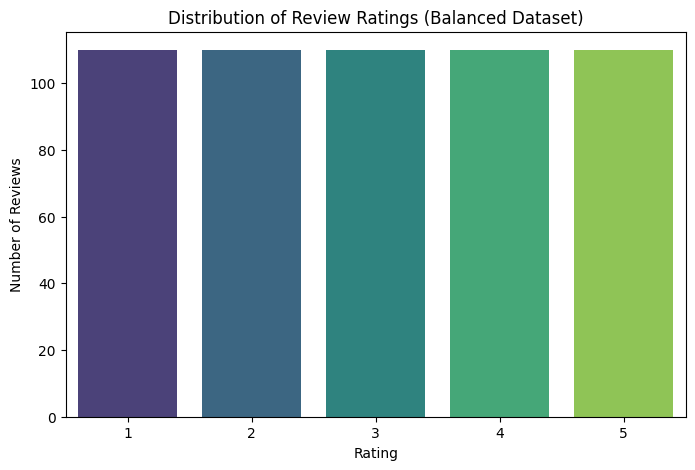


--- Word Frequency Analysis ---


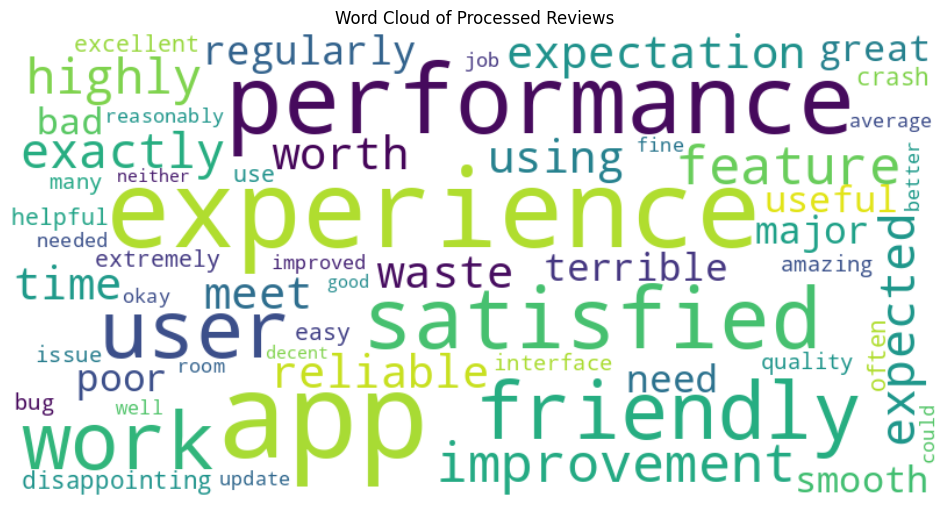

/tmp/ipykernel_1327/3622583922.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=words, y=counts, palette='magma')


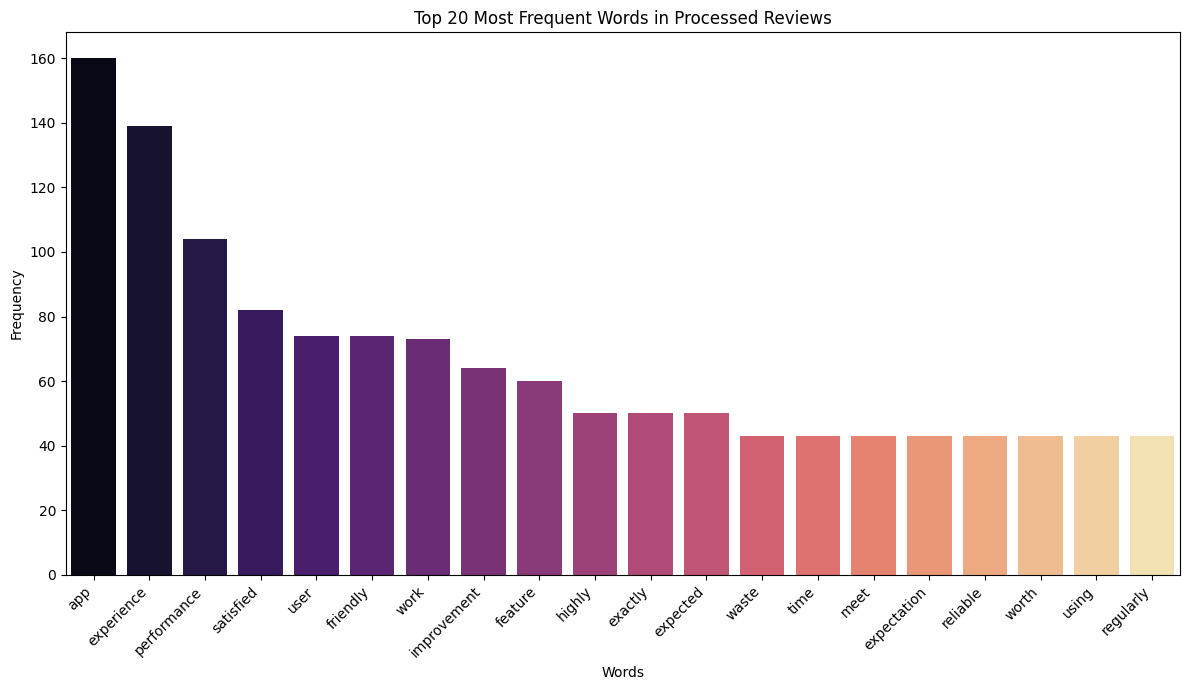

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import pandas as pd

# --- 1. Sentiment Distribution Analysis (using df_balanced) ---
print("\n--- Sentiment Distribution (df_balanced) ---")
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=df_balanced, palette='viridis')
plt.title('Distribution of Review Ratings (Balanced Dataset)')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

# --- 2. Word Frequency Analysis ---
print("\n--- Word Frequency Analysis ---")

# Combine all processed reviews into a single string
all_words = ' '.join(df['processed_review']).split()

# Get word frequencies
word_freq = Counter(all_words)

# Filter out very common short words or potential artifacts if necessary (e.g., single letters that escaped cleaning)
# For this current processed_review (where special chars are kept), word_tokenize handles most, but \n or similar might remain.
# Let's assume the 'processed_review' is clean enough from the previous step where only lowercase and tokenization happened.

# a. Word Cloud
plt.figure(figsize=(12, 8))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Processed Reviews')
plt.show()

# b. Histogram of Top N Words
n_words = 20
top_words = word_freq.most_common(n_words)

# Extract words and their counts for plotting
words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(12, 7))
sns.barplot(x=words, y=counts, palette='magma')
plt.title(f'Top {n_words} Most Frequent Words in Processed Reviews')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


--- Outlier Detection and Handling for 'helpful_votes' ---


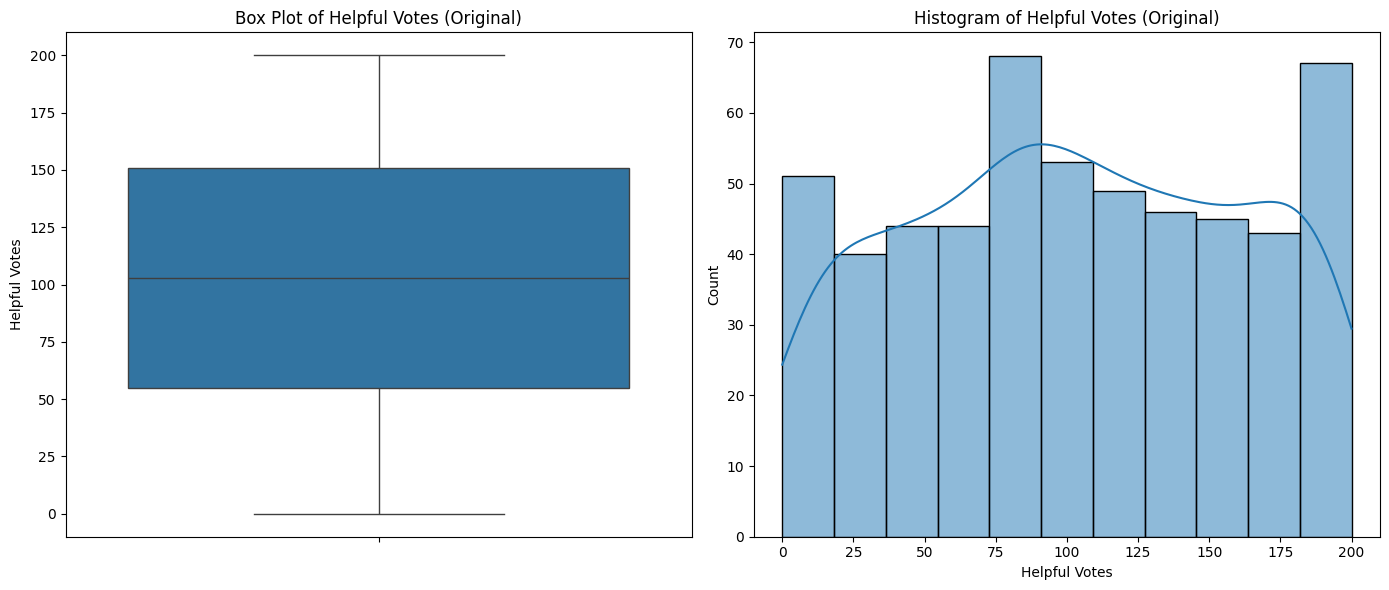


Original 'helpful_votes' statistics:
count    550.000000
mean     102.654545
std       57.930433
min        0.000000
25%       55.000000
50%      103.000000
75%      151.000000
max      200.000000
Name: helpful_votes, dtype: float64

Q1 (25th percentile): 55.0
Q3 (75th percentile): 151.0
IQR: 96.0
Lower Bound for Outliers: -89.0
Upper Bound for Outliers: 295.0

Number of outliers detected: 0
Examples of outliers:
Empty DataFrame
Columns: [helpful_votes]
Index: []

Outliers in 'helpful_votes' have been capped.


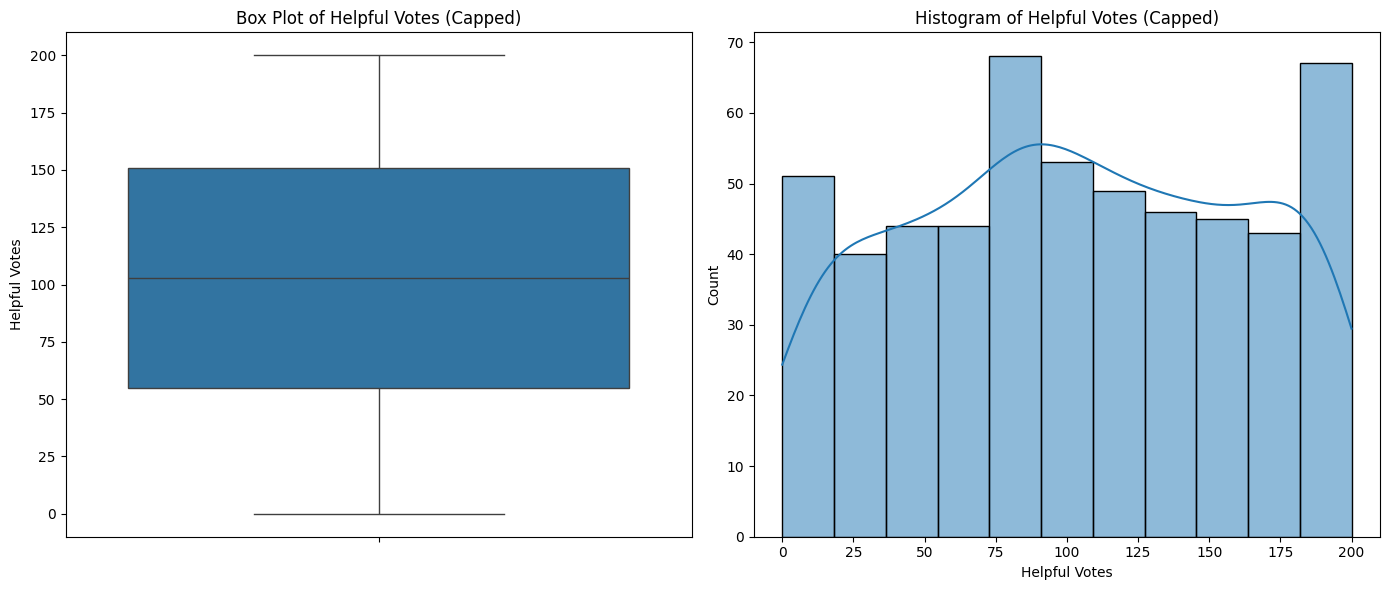


'helpful_votes' statistics after capping:
count    550.000000
mean     102.654545
std       57.930433
min        0.000000
25%       55.000000
50%      103.000000
75%      151.000000
max      200.000000
Name: helpful_votes, dtype: float64

'helpful_votes' column in df_balanced has been updated with capped values.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Outlier Detection and Handling for 'helpful_votes' ---")

# --- 1. Visualize Original Distribution ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_balanced['helpful_votes'])
plt.title('Box Plot of Helpful Votes (Original)')
plt.ylabel('Helpful Votes')

plt.subplot(1, 2, 2)
sns.histplot(df_balanced['helpful_votes'], kde=True)
plt.title('Histogram of Helpful Votes (Original)')
plt.xlabel('Helpful Votes')
plt.tight_layout()
plt.show()

print("\nOriginal 'helpful_votes' statistics:")
print(df_balanced['helpful_votes'].describe())

# --- 2. Calculate IQR and Define Outlier Bounds ---
Q1 = df_balanced['helpful_votes'].quantile(0.25)
Q3 = df_balanced['helpful_votes'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nQ1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound for Outliers: {lower_bound}")
print(f"Upper Bound for Outliers: {upper_bound}")

# --- 3. Identify Outliers ---
outliers = df_balanced[(df_balanced['helpful_votes'] < lower_bound) | (df_balanced['helpful_votes'] > upper_bound)]
print(f"\nNumber of outliers detected: {len(outliers)}")
print("Examples of outliers:")
print(outliers[['helpful_votes']].head())

# --- 4. Handle Outliers by Capping ---
df_capped = df_balanced.copy()
df_capped['helpful_votes'] = np.where(
    df_capped['helpful_votes'] > upper_bound, upper_bound,
    np.where(df_capped['helpful_votes'] < lower_bound, lower_bound, df_capped['helpful_votes'])
)

print("\nOutliers in 'helpful_votes' have been capped.")

# --- 5. Visualize Distribution After Capping ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_capped['helpful_votes'])
plt.title('Box Plot of Helpful Votes (Capped)')
plt.ylabel('Helpful Votes')

plt.subplot(1, 2, 2)
sns.histplot(df_capped['helpful_votes'], kde=True)
plt.title('Histogram of Helpful Votes (Capped)')
plt.xlabel('Helpful Votes')
plt.tight_layout()
plt.show()

print("\n'helpful_votes' statistics after capping:")
print(df_capped['helpful_votes'].describe())

# Update the main DataFrame 'df_balanced' with the capped column
df_balanced['helpful_votes'] = df_capped['helpful_votes']
print("\n'helpful_votes' column in df_balanced has been updated with capped values.")

In [ ]:
# Save the cleaned and balanced DataFrame to a CSV file
df_balanced.to_csv('cleaned_balanced_reviews.csv', index=False)

print("Cleaned and balanced data saved to 'cleaned_balanced_reviews.csv'. You can download it from the files sidebar.")

Cleaned and balanced data saved to 'cleaned_balanced_reviews.csv'. You can download it from the files sidebar.


## Sentiment Classification Mode

In [ ]:
!pip install -q transformers torch

import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np
import pandas as pd

# Load a pre-trained BERT-like tokenizer and model
# Using 'distilbert-base-uncased' for efficiency in Colab
print("Loading DistilBERT tokenizer and model...")
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
model = AutoModel.from_pretrained('distilbert-base-uncased')

# Set model to evaluation mode
model.eval()

# Move model to GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"Model moved to: {device}")

def get_bert_embeddings(texts, tokenizer, model, device, batch_size=32):
    all_embeddings = []
    # Ensure texts is a list/Series of strings, handling potential non-string entries
    texts = [str(t) for t in texts]

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        # Tokenize the batch
        # padding=True pads sequences to the length of the longest sequence in the batch
        # truncation=True truncates sequences longer than max_length
        # max_length=128 is a common choice for review texts, adjust if reviews are much longer/shorter
        inputs = tokenizer(batch_texts, return_tensors='pt', padding=True, truncation=True, max_length=128)

        # Move inputs to the same device as the model
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad(): # Disable gradient calculation for inference
            outputs = model(**inputs)

        # Get the embeddings from the last hidden state
        # We typically use the embedding of the [CLS] token (first token) as the sentence embedding
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy() # [CLS] token embeddings

        all_embeddings.append(cls_embeddings)

    return np.vstack(all_embeddings)

print("Generating BERT embeddings for processed reviews...")
# Apply the function to the 'processed_review' column of your balanced DataFrame
# Ensure 'df_balanced' and 'processed_review' are available from previous steps
bert_embeddings = get_bert_embeddings(df_balanced['processed_review'], tokenizer, model, device)

# The 'bert_embeddings' variable now holds the numerical features for each review.
# Each row corresponds to a review, and each column is a feature dimension.
print(f"Shape of generated BERT embeddings: {bert_embeddings.shape}")
print("BERT embeddings generated successfully. You can now use 'bert_embeddings' as features for your models.")

# Example of how you might use these embeddings for a model (uncomment to run):
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report

# X_bert = bert_embeddings
# y_bert = df_balanced['rating']

# X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(X_bert, y_bert, test_size=0.2, random_state=42, stratify=y_bert)

# logistic_model_bert = LogisticRegression(max_iter=1000, random_state=42)
# logistic_model_bert.fit(X_train_bert, y_train_bert)

# y_pred_bert = logistic_model_bert.predict(X_test_bert)
# print("\nClassification Report using BERT Embeddings:")
# print(classification_report(y_test_bert, y_pred_bert))


Loading DistilBERT tokenizer and model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model moved to: cuda
Generating BERT embeddings for processed reviews...
Shape of generated BERT embeddings: (550, 768)
BERT embeddings generated successfully. You can now use 'bert_embeddings' as features for your models.


In [ ]:
!pip install -q transformers torch

import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Load a pre-trained BERT-like tokenizer and model
# Using 'distilbert-base-uncased' for efficiency in Colab
print("Loading DistilBERT tokenizer and model...")
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
model = AutoModel.from_pretrained('distilbert-base-uncased')

# Set model to evaluation mode
model.eval()

# Move model to GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"Model moved to: {device}")

def get_bert_embeddings(texts, tokenizer, model, device, batch_size=32):
    all_embeddings = []
    # Ensure texts is a list/Series of strings, handling potential non-string entries
    texts = [str(t) for t in texts]

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        # Tokenize the batch
        # padding=True pads sequences to the length of the longest sequence in the batch
        # truncation=True truncates sequences longer than max_length
        # max_length=128 is a common choice for review texts, adjust if reviews are much longer/shorter
        inputs = tokenizer(batch_texts, return_tensors='pt', padding=True, truncation=True, max_length=128)

        # Move inputs to the same device as the model
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad(): # Disable gradient calculation for inference
            outputs = model(**inputs)

        # Get the embeddings from the last hidden state
        # We typically use the embedding of the [CLS] token (first token) as the sentence embedding
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy() # [CLS] token embeddings

        all_embeddings.append(cls_embeddings)

    return np.vstack(all_embeddings)

print("Generating BERT embeddings for processed reviews...")
# Apply the function to the 'processed_review' column of your balanced DataFrame
# Ensure 'df_balanced' and 'processed_review' are available from previous steps
bert_embeddings = get_bert_embeddings(df_balanced['processed_review'], tokenizer, model, device)

# The 'bert_embeddings' variable now holds the numerical features for each review.
# Each row corresponds to a review, and each column is a feature dimension.
print(f"Shape of generated BERT embeddings: {bert_embeddings.shape}")
print("BERT embeddings generated successfully. You can now use 'bert_embeddings' as features for your models.")

# Example of how you might use these embeddings for a model:
X_bert = bert_embeddings
y_bert = df_balanced['rating']

X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(X_bert, y_bert, test_size=0.2, random_state=42, stratify=y_bert)

logistic_model_bert = LogisticRegression(max_iter=1000, random_state=42)
logistic_model_bert.fit(X_train_bert, y_train_bert)

y_pred_bert = logistic_model_bert.predict(X_test_bert)
print("\nClassification Report using BERT Embeddings:")
print(classification_report(y_test_bert, y_pred_bert))

Loading DistilBERT tokenizer and model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model moved to: cuda
Generating BERT embeddings for processed reviews...
Shape of generated BERT embeddings: (550, 768)
BERT embeddings generated successfully. You can now use 'bert_embeddings' as features for your models.

Classification Report using BERT Embeddings:
              precision    recall  f1-score   support

           1       0.53      0.41      0.46        22
           2       0.52      0.64      0.57        22
           3       1.00      1.00      1.00        22
           4       0.67      0.45      0.54        22
           5       0.59      0.77      0.67        22

    accuracy                           0.65       110
   macro avg       0.66      0.65      0.65       110
weighted avg       0.66      0.65      0.65       110



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Prepare data for modeling
X = df_balanced['processed_review']  # Features (processed text)
y = df_balanced['rating']            # Target (ratings)

# Split data into training and testing sets
# Stratify by y to maintain the balanced class distribution in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n--- Text Vectorization using TF-IDF ---")
# Initialize TF-IDF Vectorizer
# max_features can be adjusted to limit the number of features
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
# Transform the testing data (do not fit on test data to prevent data leakage)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

print("\n--- Training Logistic Regression Model ---")
# Initialize and train Logistic Regression model
# max_iter can be increased for convergence if needed
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully.")

print("\n--- Evaluating Model Performance ---")
# Make predictions on the test set
y_pred = logistic_model.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display classification report for more detailed metrics (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



--- Text Vectorization using TF-IDF ---
Shape of X_train_tfidf: (440, 57)
Shape of X_test_tfidf: (110, 57)

--- Training Logistic Regression Model ---
Logistic Regression model trained successfully.

--- Evaluating Model Performance ---
Accuracy: 0.6545

Classification Report:
              precision    recall  f1-score   support

           1       0.53      0.41      0.46        22
           2       0.52      0.64      0.57        22
           3       1.00      1.00      1.00        22
           4       0.67      0.45      0.54        22
           5       0.59      0.77      0.67        22

    accuracy                           0.65       110
   macro avg       0.66      0.65      0.65       110
weighted avg       0.66      0.65      0.65       110



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("\n--- Training Random Forest Classifier ---")

# Initialize the Random Forest Classifier
# n_estimators: number of trees in the forest
# random_state: for reproducibility
# You can tune other parameters like max_depth, min_samples_split, etc.
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using the TF-IDF vectorized training data
random_forest_model.fit(X_train_tfidf, y_train)

print("Random Forest Classifier trained successfully.")

print("\n--- Evaluating Random Forest Model Performance ---")
# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test_tfidf)

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy (Random Forest): {accuracy_rf:.4f}")

# Display classification report for more detailed metrics
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))


--- Training Random Forest Classifier ---
Random Forest Classifier trained successfully.

--- Evaluating Random Forest Model Performance ---
Accuracy (Random Forest): 0.6545

Classification Report (Random Forest):
              precision    recall  f1-score   support

           1       0.53      0.41      0.46        22
           2       0.52      0.64      0.57        22
           3       1.00      1.00      1.00        22
           4       0.67      0.45      0.54        22
           5       0.59      0.77      0.67        22

    accuracy                           0.65       110
   macro avg       0.66      0.65      0.65       110
weighted avg       0.66      0.65      0.65       110



In [ ]:
import pickle
from sklearn.ensemble import RandomForestClassifier

model_filename_rf = 'random_forest_model.pkl'


with open(model_filename_rf, 'wb') as file:
    pickle.dump(random_forest_model, file)

print(f"Random Forest model saved to '{model_filename_rf}'")

loaded_rf_model = None
with open(model_filename_rf, 'rb') as file:
    loaded_rf_model = pickle.load(file)

print(f"\nRandom Forest model loaded from '{model_filename_rf}'")
print(f"Type of loaded model: {type(loaded_rf_model)}")

print("\n--- Random Forest Model Initialization ---")
print("Model initialization typically involves creating an instance of the model class.")
print("For example, a new Random Forest model is initialized like this:")
print("new_random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)")
print("This step is usually followed by training (e.g., new_random_forest_model.fit(X_train, y_train)).")

Random Forest model saved to 'random_forest_model.pkl'

Random Forest model loaded from 'random_forest_model.pkl'
Type of loaded model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>

--- Random Forest Model Initialization ---
Model initialization typically involves creating an instance of the model class.
For example, a new Random Forest model is initialized like this:
new_random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
This step is usually followed by training (e.g., new_random_forest_model.fit(X_train, y_train)).


## Model Evaluation

In [ ]:
from sklearn.metrics import roc_auc_score

print("\n--- Further Model Evaluation for Logistic Regression ---")

# Get prediction probabilities for AUC-ROC calculation
# The logistic_model and X_test_tfidf are available from previous execution
y_pred_proba = logistic_model.predict_proba(X_test_tfidf)

# Calculate AUC-ROC score (for multi-class, use 'ovr' and 'weighted' or 'macro' averaging)
# 'ovr': One-vs-Rest (calculates AUC for each class against all others)
# 'weighted': Calculate metrics for each label, and find their average weighted by support (the number of true instances for each label).
auc_roc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

print(f"AUC-ROC Score (Weighted, One-vs-Rest): {auc_roc:.4f}")

# Re-display classification report for convenience
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred))


--- Further Model Evaluation for Logistic Regression ---
AUC-ROC Score (Weighted, One-vs-Rest): 0.9013

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           1       0.53      0.41      0.46        22
           2       0.52      0.64      0.57        22
           3       1.00      1.00      1.00        22
           4       0.67      0.45      0.54        22
           5       0.59      0.77      0.67        22

    accuracy                           0.65       110
   macro avg       0.66      0.65      0.65       110
weighted avg       0.66      0.65      0.65       110




--- Confusion Matrix (Logistic Regression) ---


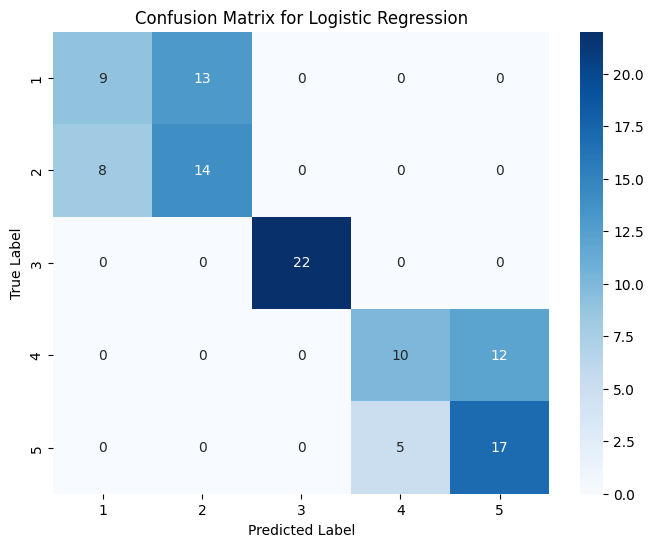


--- AUC-ROC Curve (One-vs-Rest for Logistic Regression) ---


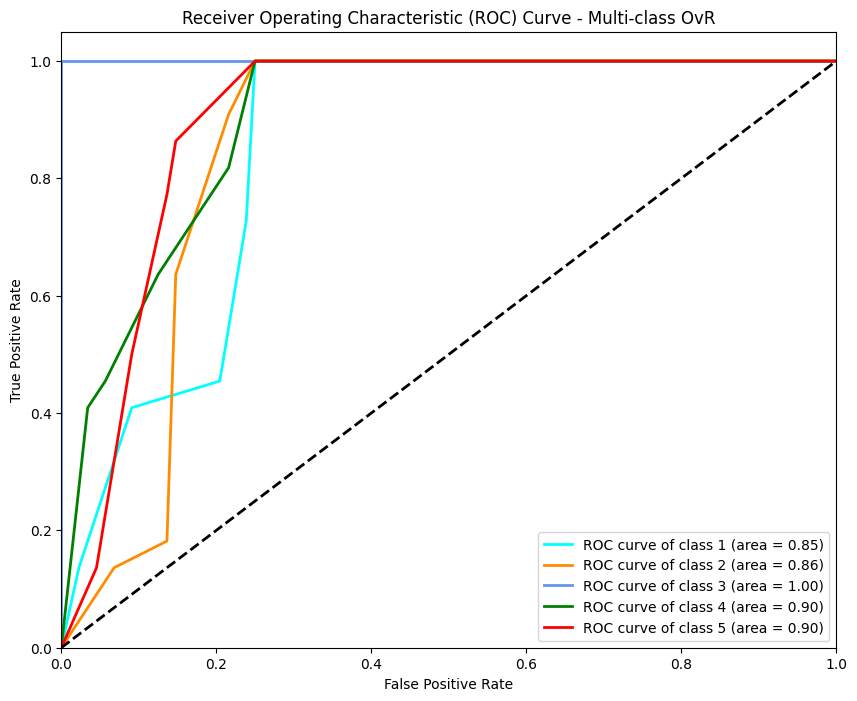

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Confusion Matrix ---
print("\n--- Confusion Matrix (Logistic Regression) ---")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=logistic_model.classes_,
            yticklabels=logistic_model.classes_)
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- AUC-ROC Curve ---
print("\n--- AUC-ROC Curve (One-vs-Rest for Logistic Regression) ---")

# Binarize the output for multi-class ROC curve
y_test_binarized = label_binarize(y_test, classes=logistic_model.classes_)
n_classes = y_test_binarized.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {logistic_model.classes_[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Multi-class OvR')
plt.legend(loc='lower right')
plt.show()

## STREAMLIT APPLICATION



--- Overall Sentiment Distribution ---
sentiment_category
Negative    40.0
Positive    40.0
Neutral     20.0
Name: proportion, dtype: float64


/tmp/ipykernel_1327/535578278.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_proportions.index, y=sentiment_proportions.values, palette='coolwarm')


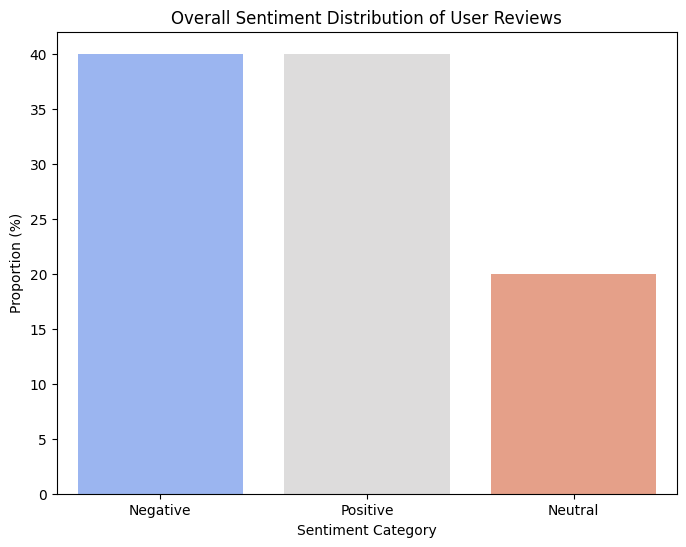

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map ratings to sentiment categories
def map_sentiment(rating):
    if rating in [1, 2]:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    elif rating in [4, 5]:
        return 'Positive'
    return 'Unknown'

df_balanced['sentiment_category'] = df_balanced['rating'].apply(map_sentiment)

# 2. Compute proportions of each sentiment category
sentiment_proportions = df_balanced['sentiment_category'].value_counts(normalize=True) * 100
print("\n--- Overall Sentiment Distribution ---")
print(sentiment_proportions)

# 3. Visualize the overall sentiment distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_proportions.index, y=sentiment_proportions.values, palette='coolwarm')
plt.title('Overall Sentiment Distribution of User Reviews')
plt.xlabel('Sentiment Category')
plt.ylabel('Proportion (%)')
plt.show()

In [ ]:
!pip install streamlit pandas plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 30.2 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
from textblob import TextBlob

# 1. Page Configuration
st.set_page_config(page_title="AI Review Analytics Dashboard", layout="wide", page_icon="🤖")

# 2. Data Loading & Cleaning
@st.cache_data
def load_and_clean_data():
    # Load the dataset
    df = pd.read_csv('cleaned_balanced_reviews.csv')

    # Clean column names (strip spaces and lowercase for consistency)
    df.columns = df.columns.str.strip().str.lower()

    # Handle Sentiment Category (if missing or for consistency)
    if 'sentiment_category' not in df.columns:
        def classify(r):
            if r >= 4: return 'Positive'
            elif r == 3: return 'Neutral'
            else: return 'Negative'
        df['sentiment_category'] = df['rating'].apply(classify)

    # Handle Dates (Convert '########' to NaT)
    df['date_dt'] = pd.to_datetime(df['date'], errors='coerce')

    # Fill empty reviews to prevent errors
    df['processed_review'] = df['processed_review'].fillna('')
    df['review'] = df['review'].fillna('')

    return df

# Load data
df = load_and_clean_data()

# 3. Sidebar Navigation & Filters
st.sidebar.title("Dashboard Controls")
st.sidebar.info(f"Total Reviews: {len(df)}")

# Global Filters
platforms = df['platform'].unique().tolist()
selected_platforms = st.sidebar.multiselect("Select Platforms", platforms, default=platforms)

sentiments = df['sentiment_category'].unique().tolist()
selected_sentiments = st.sidebar.multiselect("Select Sentiments", sentiments, default=sentiments)

# Filter logic
filtered_df = df[
    (df['platform'].isin(selected_platforms)) &
    (df['sentiment_category'].isin(selected_sentiments))
]

# 4. Main UI Header
st.title("🚀 ChatGPT User Review Insights")
st.markdown("Comprehensive analysis of user sentiment, platform performance, and feedback themes.")

# 5. Define Dashboard Tabs
tab_overview, tab_trends, tab_user, tab_themes, tab_predictor = st.tabs([
    "📊 Overview",
    "📈 Sentiment Trends",
    "👥 User & Platform",
    "🔍 Negative Themes",
    "🔮 Sentiment Predictor"
])

# --- TAB 1: OVERVIEW (Points 1, 2, 6) ---
with tab_overview:
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("1. Overall Sentiment Distribution")
        sent_counts = filtered_df['sentiment_category'].value_counts().reset_index()
        fig1 = px.pie(sent_counts, names='sentiment_category', values='count',
                     hole=0.4, color='sentiment_category',
                     color_discrete_map={'Positive':'#2ecc71', 'Neutral':'#95a5a6', 'Negative':'#e74c3c'})
        st.plotly_chart(fig1, use_container_width=True)

    with col2:
        st.subheader("2. Rating vs. Sentiment Mismatch")
        fig2 = px.box(filtered_df, x='rating', y='sentiment_category', color='sentiment_category',
                     points="all", title="Check for Rating-Sentiment Mismatches")
        st.plotly_chart(fig2, use_container_width=True)

    st.divider()
    st.subheader("6. Review Length Impact")
    fig6 = px.scatter(filtered_df, x='review_length', y='rating', color='sentiment_category',
                     size='helpful_votes', hover_data=['username'],
                     title="Review Length vs Rating (Size = Helpful Votes)")
    st.plotly_chart(fig6, use_container_width=True)

# --- TAB 2: TRENDS (Points 4, 9) ---
with tab_trends:
    st.subheader("4. Sentiment Trends Over Time")
    time_df = filtered_df[filtered_df['date_dt'].notna()].copy()
    if not time_df.empty:
        time_df['Month'] = time_df['date_dt'].dt.to_period('M').astype(str)
        trend = time_df.groupby(['Month', 'sentiment_category']).size().reset_index(name='count')
        fig4 = px.line(trend, x='Month', y='count', color='sentiment_category', markers=True)
        st.plotly_chart(fig4, use_container_width=True)
    else:
        st.warning("No valid dates available in the current selection for trend lines.")

    st.divider()
    st.subheader("9. Sentiment by Version Release")
    ver_df = filtered_df.groupby(['version', 'sentiment_category']).size().reset_index(name='count')
    fig9 = px.bar(ver_df, x='version', y='count', color='sentiment_category', barmode='group')
    st.plotly_chart(fig9, use_container_width=True)

# --- TAB 3: USER PROFILING (Points 5, 7, 8) ---
with tab_user:
    col_a, col_b = st.columns(2)

    with col_a:
        st.subheader("5. Verified Purchase Impact")
        fig5 = px.histogram(filtered_df, x='verified_purchase', color='sentiment_category', barmode='group')
        st.plotly_chart(fig5, use_container_width=True)

    with col_b:
        st.subheader("8. Platform Comparison")
        fig8 = px.bar(filtered_df.groupby(['platform', 'sentiment_category']).size().reset_index(name='count'),
                     x='platform', y='count', color='sentiment_category')
        st.plotly_chart(fig8, use_container_width=True)

    st.divider()
    st.subheader("7. Regional Sentiment (Top 10 Locations)")
    top_locs = filtered_df['location'].value_counts().nlargest(10).index
    loc_df = filtered_df[filtered_df['location'].isin(top_locs)]
    fig7 = px.bar(loc_df.groupby(['location', 'sentiment_category']).size().reset_index(name='count'),
                 x='location', y='count', color='sentiment_category', barmode='stack')
    st.plotly_chart(fig7, use_container_width=True)

# --- TAB 4: THEMES & KEYWORDS (Points 3, 10) ---
with tab_themes:
    st.subheader("3. Common Keywords")
    target_s = st.segmented_control("Filter keywords for sentiment:", options=['Positive', 'Neutral', 'Negative'], default='Negative')

    text_data = " ".join(filtered_df[filtered_df['sentiment_category'] == target_s]['processed_review']).lower().split()
    # Filter common stop words manually
    stop_words = {'this', 'that', 'with', 'from', 'have', 'very', 'just', 'more'}
    words = [w for w in text_data if len(w) > 4 and w not in stop_words]

    word_freq = pd.DataFrame(Counter(words).most_common(15), columns=['Word', 'Count'])
    fig3 = px.bar(word_freq, x='Count', y='Word', orientation='h', color='Count', color_continuous_scale='Reds' if target_s == 'Negative' else 'Greens')
    st.plotly_chart(fig3, use_container_width=True)

    st.divider()
    st.subheader("10. Most Common Negative Feedback Themes")
    neg_reviews = df[df['sentiment_category'] == 'Negative']['processed_review'].astype(str)
    neg_words = [w for w in " ".join(neg_reviews).lower().split() if len(w) > 5 and w not in stop_words]
    theme_df = pd.DataFrame(Counter(neg_words).most_common(10), columns=['Issue Topic', 'Frequency'])
    st.table(theme_df)

# --- TAB 5: LIVE SENTIMENT PREDICTOR ---
with tab_predictor:
    st.header("🔮 Real-Time Sentiment Predictor")
    st.write("Type a review below to predict its sentiment category.")

    user_input = st.text_area("User Review Text:", placeholder="e.g., The app is fast and easy to use, but sometimes it crashes on the home screen.")

    if st.button("Analyze Sentiment"):
        if user_input:
            # Calculation
            analysis = TextBlob(user_input)
            polarity = analysis.sentiment.polarity

            # Classification
            if polarity > 0.1:
                label = "Positive"
                st.success(f"### Predicted Sentiment: {label} 😊")
            elif polarity < -0.1:
                label = "Negative"
                st.error(f"### Predicted Sentiment: {label} 😡")
            else:
                label = "Neutral"
                st.info(f"### Predicted Sentiment: {label} 😐")

            # Detailed Breakdown
            st.write(f"**Polarity Score:** {round(polarity, 2)}")
            st.progress((polarity + 1) / 2)
            st.caption("Scale: -1.0 (Very Negative) to 1.0 (Very Positive)")
        else:
            st.warning("Please enter some text to analyze.")

# Footer
st.sidebar.markdown("---")
st.sidebar.caption("Dashboard developed for Review Analysis Analysis.")

Writing app.py


In [ ]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

--2026-03-18 10:07:20--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64 [following]
--2026-03-18 10:07:20--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/731ab2f8-6b77-4adb-a7b3-1104525e9d72?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-18T10%3A42%3A00Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-

In [ ]:
!streamlit run /content/app.py &>/content/logs.txt &

In [ ]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://lemon-completion-sister-jesus.trycloudflare.com
